### About the dataset

This Online Retail II data set contains all the transactions occurring for a UK-based and registered, non-store online retail between 01/12/2009 and 09/12/2011.The company mainly sells unique all-occasion gift-ware. Many customers of the company are wholesalers

I'll use unsupervised learning algorithms to find the hidden patterns of dataset, to use them later in business for the customer type clustering.

E.g. company can use it to understand which customers are at risk of quiting the service and it'll help company to start reactivation campaign or stop spending budget on them.

On the other side if customer is buying a lot, company can make personalized offer to increase their products selling even more.

---

### Import & Basic analysis

In [216]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [217]:
df = pd.read_csv("../data/raw/online_retail_II.csv")

In [218]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [219]:
df.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628,5305,5698,NaN,47635,NaN,NaN,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2010-12-06 16:57:00,NaN,NaN,United Kingdom
freq,1350,5829,5918,NaN,1350,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,NaN,4.649388e+00,15324.638504,NaN
std,NaN,NaN,NaN,1.727058e+02,NaN,1.235531e+02,1697.464450,NaN
min,NaN,NaN,NaN,-8.099500e+04,NaN,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,NaN,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,NaN,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,NaN,4.150000e+00,16797.000000,NaN


In [220]:
df.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [221]:
df.duplicated().sum()

np.int64(34335)

In [222]:
df.shape

(1067371, 8)

### Handling missing values

In [223]:
df = df.drop(columns=['Description'])

`Description feature` doesn't represent any useful information, so i'll drop it

In [224]:
print(f"NA values are {df["Customer ID"].isna().mean().round(3) * 100}% of whole dataset")

NA values are 22.8% of whole dataset


NA values of `Customer ID` will be dropped, even though it's almost 1/4 of dataset.

The reason for it - is that for our task it's must-have to know which customer bought which product, because in other way we won't be able to determine clusters precisely.

In [225]:
df = df.dropna(axis=0)

In [226]:
df.isna().sum().any()

np.False_

### Handling duplicates

In [227]:
df[df.duplicated(keep=False)].sort_values(
    ["Invoice", "StockCode", "Customer ID"]
).head(6)

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country
379,489517,21491,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
391,489517,21491,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
365,489517,21821,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
371,489517,21912,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


They are represent same information so it's reasonable to drop them to no tdidstort the model.

In [228]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print(f"Removed: {before - after:,}")
print(f"Remaining: {after:,}")

Removed: 26,481
Remaining: 797,883


In [229]:
df.duplicated().any()

np.False_

---

### Handling cancellations and values under zero

If `Invoice` feature's value starts with `c` it means there was a cancellation

In [230]:
df['is_cancelled'] = df['Invoice'].astype(str).str.startswith('C')

In [231]:
df.groupby("is_cancelled")["Quantity"].agg(["count", "mean", "sum"])

,count,mean,sum
is_cancelled,,,
False,779493,13.506731,10528402
True,18390,-25.719195,-472976


I will drop cancelled rows since i want clean dataset without cancellation

In [232]:
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df.drop(columns=['is_cancelled'])

In [233]:
(df["Quantity"] < 0).sum()

np.int64(0)

In [234]:
(df["Price"] <= 0).sum()

np.int64(70)

In [235]:
df[df["Price"] <= 0][
    ["Invoice", "StockCode", "Quantity", "Price"]
].head(12)

,Invoice,StockCode,Quantity,Price
4674,489825,22076,12,0.0
6781,489998,48185,2,0.0
16107,490727,M,1,0.0
18738,490961,22065,1,0.0
18739,490961,22142,12,0.0
32916,492079,85042,8,0.0
40101,492760,21143,12,0.0
47126,493761,79320,24,0.0
48342,493899,22355,10,0.0
57619,494607,21533,12,0.0


Those rows are invalid and must be dropped

In [236]:
df = df[~(df['Price'] <= 0)]

---

### Outliers handling

Let's create Revenue feature which will be pretty useful in the future.

In [237]:
df['Revenue'] = df['Quantity'] * df['Price']

In [238]:
df["Quantity"].describe()

count    779423.000000
mean         13.489016
std         145.855640
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

In [239]:
df["Price"].describe()

count    779423.000000
mean          3.218488
std          29.676178
min           0.001000
25%           1.250000
50%           1.950000
75%           3.750000
max       10953.500000
Name: Price, dtype: float64

I noticed those two features has the biggest gap between min and max values

In [240]:
df.nlargest(20, "Quantity")[
    ["Invoice", "StockCode", "Quantity", "Price", "Customer ID"]
]

,Invoice,StockCode,Quantity,Price,Customer ID
1065882,581483,23843,80995,2.08,16446.0
587080,541431,23166,74215,1.04,12346.0
90857,497946,37410,19152,0.10,13902.0
127166,501534,21099,12960,0.10,13902.0
127168,501534,21091,12960,0.10,13902.0
127169,501534,21085,12744,0.10,13902.0
127167,501534,21092,12480,0.10,13902.0
135027,502269,21984,10000,0.25,17940.0
135028,502269,21982,10000,0.25,17940.0
135029,502269,21980,10000,0.25,17940.0


In [241]:
df.nlargest(20, "Price")[
    ["Invoice", "StockCode", "Quantity", "Price", "Customer ID"]
]

,Invoice,StockCode,Quantity,Price,Customer ID
135013,502263,M,1,10953.50,12918.0
358639,524159,M,1,10468.80,14063.0
74356,496115,M,1,8985.60,17949.0
698843,551697,POST,1,8142.75,16029.0
129903,501766,M,1,6958.17,15760.0
129987,501768,M,1,6958.17,15760.0
947835,573077,M,1,4161.06,12536.0
947838,573080,M,1,4161.06,12536.0
931867,571751,M,1,3949.32,12744.0
288706,517483,M,1,3610.50,12737.0


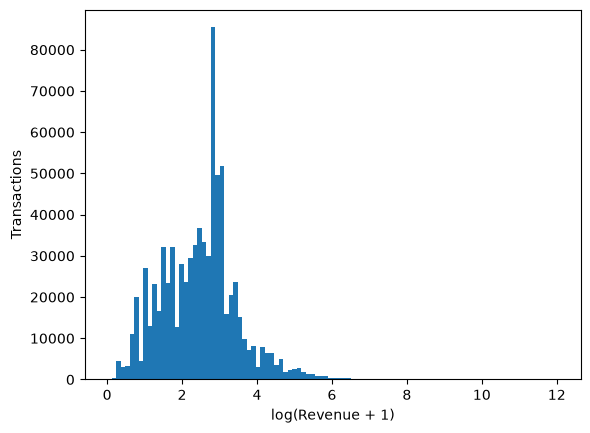

In [242]:
plt.hist(np.log1p(df["Revenue"]), bins=100)
plt.xlabel("log(Revenue + 1)")
plt.ylabel("Transactions")
plt.show()

In [243]:
Q1 = df["Revenue"].quantile(0.25)
Q3 = df["Revenue"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Revenue"] < lower) |
    (df["Revenue"] > upper)
]

len(outliers)

63561

The product-outliers in this dataset are either:
- very cheap and sold in very high quantity

- very expensive and sold once

Which represents normal product sales and can't be dropped.

---

### Encoding of categorical features

In [244]:
cat_cols = ['StockCode', 'Country', 'Customer ID']

df[cat_cols].nunique()

StockCode      4631
Country          41
Customer ID    5878
dtype: int64

In [245]:
df['Country'].value_counts(normalize=True) * 100

Country
United Kingdom          89.859550
Germany                  2.108226
EIRE                     1.996990
France                   1.733462
Netherlands              0.652406
Spain                    0.469835
Belgium                  0.391957
Switzerland              0.385542
Portugal                 0.302275
Australia                0.229529
Channel Islands          0.198993
Italy                    0.185009
Sweden                   0.168971
Norway                   0.165379
Cyprus                   0.145749
Finland                  0.132406
Austria                  0.118293
Denmark                  0.099817
Greece                   0.084293
Unspecified              0.066459
Poland                   0.064663
Japan                    0.060044
USA                      0.052475
United Arab Emirates     0.049139
Singapore                0.043494
Israel                   0.040928
Malta                    0.036181
Canada                   0.029252
Iceland                  0.028483
Lithua

Instead of encoding this feature I'll seperate it into 2 new ones later in feature engineering:
- `is_uk` because 89% of all product sales located in UK

- `is_not_uk` will be the rest of countries.

`Customer ID` can't be dropped or encoded because it represents customers that will be used later in clustering.

---

### Wrong dtypes

In [246]:
df.dtypes

Invoice         object
StockCode       object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
Revenue        float64
dtype: object

In [247]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

### Feature engineering  

In [248]:
df.head()

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


I can't get any useful information from ID features such as:
- `Invoice` because it's basically id of transactions and I dropped cancelled ones, so nothing special here

- `StockCode` - id for the product.

-  and `CustomerID` - id for customers.

Those features will be used in grouping.

---

Let's start with behavioral features.

In [249]:
df['avg_unit_price'] = df.groupby('Customer ID')['Price'].transform('mean')

df['avg_order_value'] = df.groupby(['Customer ID', 'Invoice'])['Revenue'].transform('sum').groupby(df['Customer ID']).transform('mean')

df['avg_items_per_order'] = df.groupby(['Customer ID', 'Invoice'])['Quantity'].transform('sum').groupby(df['Customer ID']).transform('mean')

df['max_item_price'] = df.groupby(['Customer ID'])['Price'].transform('max')